In [1]:
import cogsworth
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from scipy.integrate import cumulative_trapezoid
from astropy.coordinates import SkyCoord

import sys
sys.path.append('../src')
import plotting, helpers
from importlib import reload

In [2]:
%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [93]:
reload(helpers)
n_parts = 1

pops = [
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/qcflag-5", n_parts, label="Fryer+2012 Delayed", colour="C0"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/mandel-muller", n_parts, label="Mandel & Muller 2020", colour="C1"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-fallback-0.0", n_parts, label="Maltsev 2025 (fb=0.0)", colour="C2"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-fallback-0.25", n_parts, label="Maltsev 2025 (fb=0.25)", colour="C3"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-fallback-0.5", n_parts, label="Maltsev 2025 (fb=0.5)", colour="C4"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-fallback-0.75", n_parts, label="Maltsev 2025 (fb=0.75)", colour="C5"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-fallback-1.0", n_parts, label="Maltsev 2025 (fb=1.0)", colour="C6"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-pf-prob-0.0", n_parts, label="Maltsev 2025 (P(pf)=0.0)", colour="C7"),
    helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/maltsev-pf-prob-1.0", n_parts, label="Maltsev 2025 (P(pf)=1.0)", colour="C8"),
    # helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/binaries-remnantflag-3", n_parts, label="Fryer+2012 Rapid", colour="C1"),
    # helpers.load_distributed_pop("/mnt/ceph/users/twagg/underworld/binaries-remnantflag-2", n_parts, label="StarTrack", colour="C2"),
]

Loading distributed population Fryer+2012 Delayed from 1 parts
   loaded part 1/1 of Fryer+2012 Delayed with 179379 binaries
Loading distributed population Mandel & Muller 2020 from 1 parts
   loaded part 1/1 of Mandel & Muller 2020 with 179381 binaries
Loading distributed population Maltsev 2025 (fb=0.0) from 1 parts
   loaded part 1/1 of Maltsev 2025 (fb=0.0) with 179381 binaries
Loading distributed population Maltsev 2025 (fb=0.25) from 1 parts
   loaded part 1/1 of Maltsev 2025 (fb=0.25) with 179381 binaries
Loading distributed population Maltsev 2025 (fb=0.5) from 1 parts
   loaded part 1/1 of Maltsev 2025 (fb=0.5) with 179379 binaries
Loading distributed population Maltsev 2025 (fb=0.75) from 1 parts
   loaded part 1/1 of Maltsev 2025 (fb=0.75) with 179380 binaries
Loading distributed population Maltsev 2025 (fb=1.0) from 1 parts
   loaded part 1/1 of Maltsev 2025 (fb=1.0) with 179380 binaries
Loading distributed population Maltsev 2025 (P(pf)=0.0) from 1 parts
   loaded part 1/1

In [94]:
kinematics = helpers.get_kinematics(pops)

[ 4.84019975 17.4872343  32.95324306 36.93169932]
[ 3.52408982 15.303881   37.68115419 24.31849477]
[ 7.23532449 31.95149908 71.99890231 45.6040391 ]
[ 6.75594273 31.64068354 70.86840864 39.88282988]
[ 6.15606001 27.56449119 57.21173109 42.09956739]
[ 6.86352331 30.74003505 69.39666358 37.33511424]
[ 6.71152016 31.32964765 72.4126543  41.65802277]
[ 7.20766151 31.3258019  70.7348249  43.43357563]
[ 4.96213989 17.51644314 33.21356195 41.99544667]


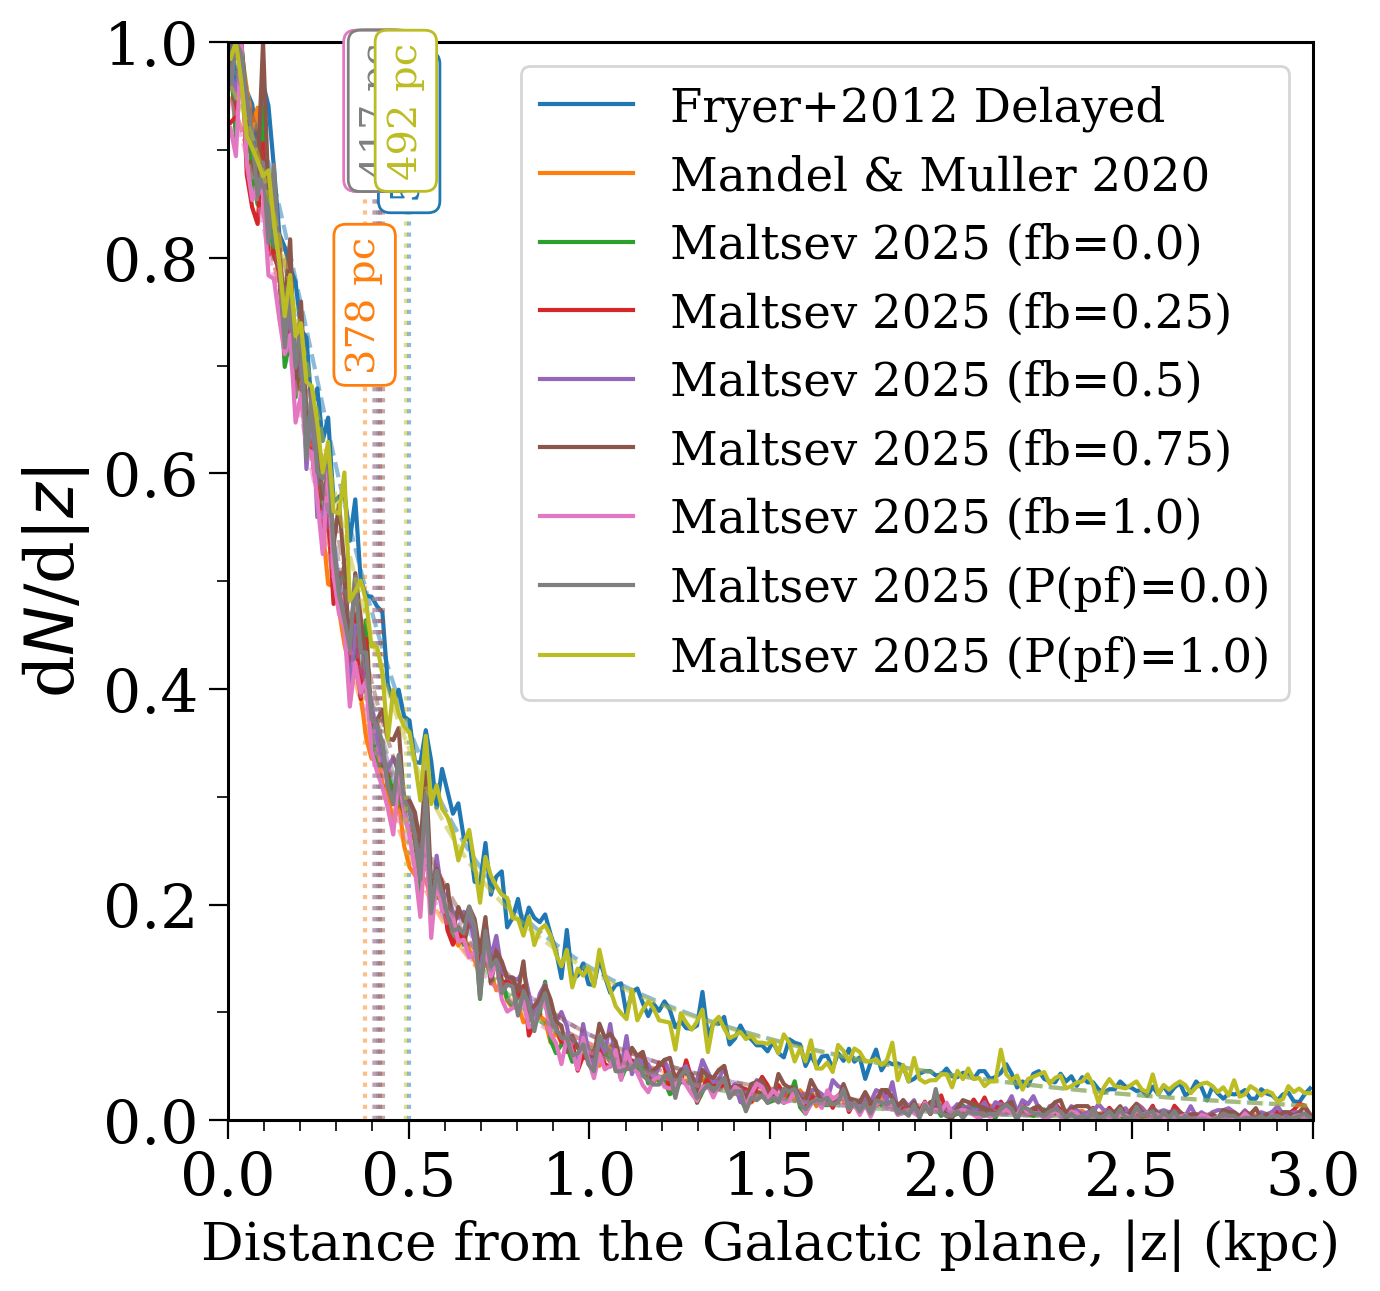

In [95]:
fig, ax = plt.subplots(figsize=(7, 7))

for pop, loc in zip(pops, [0.98, 0.82, 1,1,1,1,1,1,1]):
    scale_height, _, _ = plotting.estimate_scale_height(
        z=kinematics[pop.label]["pos"]["BH"][:, 2][~kinematics[pop.label]["escaped"]["BH"]],
        plot=True,
        label=pop.label,
        colour=pop.colour,
        show=False,
        fig=fig,
        ax=ax,
        bins=np.linspace(0, 3, 201),
        xlim=(0, 3),
        ylim=(0, 1),
        n_components=2,
        scale_height_locs=[loc]
    )


ax.xaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))
ax.yaxis.set_minor_locator(mpl.ticker.MultipleLocator(0.1))

# plt.savefig("../plots/scale_height_rmp.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [96]:
scale_up = 6e10 / pops[0].mass_binaries

In [97]:
for i, pop in enumerate(pops):
    n_ns = (pop.final_bpp["kstar_1"] == 13).sum() + (pop.final_bpp["kstar_2"] == 13).sum()
    n_bh = (pop.final_bpp["kstar_1"] == 14).sum() + (pop.final_bpp["kstar_2"] == 14).sum()
    print(f"{pop.label}\n  Total: {n_ns + n_bh}, NSs: {n_ns}, BHs: {n_bh}")
    print(f"  Scaled totals: {(n_ns + n_bh) * scale_up:1.1e}, NSs: {n_ns * scale_up:1.1e}, BHs: {n_bh * scale_up:1.1e}")


Fryer+2012 Delayed
  Total: 199978, NSs: 144196, BHs: 55782
  Scaled totals: 6.6e+08, NSs: 4.8e+08, BHs: 1.8e+08
Mandel & Muller 2020
  Total: 199252, NSs: 129876, BHs: 69376
  Scaled totals: 6.6e+08, NSs: 4.3e+08, BHs: 2.3e+08
Maltsev 2025 (fb=0.0)
  Total: 200386, NSs: 186902, BHs: 13484
  Scaled totals: 6.6e+08, NSs: 6.2e+08, BHs: 4.4e+07
Maltsev 2025 (fb=0.25)
  Total: 200391, NSs: 185494, BHs: 14897
  Scaled totals: 6.6e+08, NSs: 6.1e+08, BHs: 4.9e+07
Maltsev 2025 (fb=0.5)
  Total: 200330, NSs: 184332, BHs: 15998
  Scaled totals: 6.6e+08, NSs: 6.1e+08, BHs: 5.3e+07
Maltsev 2025 (fb=0.75)
  Total: 200326, NSs: 184255, BHs: 16071
  Scaled totals: 6.6e+08, NSs: 6.1e+08, BHs: 5.3e+07
Maltsev 2025 (fb=1.0)
  Total: 200346, NSs: 184297, BHs: 16049
  Scaled totals: 6.6e+08, NSs: 6.1e+08, BHs: 5.3e+07
Maltsev 2025 (P(pf)=0.0)
  Total: 200312, NSs: 186831, BHs: 13481
  Scaled totals: 6.6e+08, NSs: 6.2e+08, BHs: 4.4e+07
Maltsev 2025 (P(pf)=1.0)
  Total: 200104, NSs: 161027, BHs: 39077
  Sca

Inner 10 kpc
  Fryer+2012 Delayed fraction within 0.5 kpc 0.49
  Mandel & Muller 2020 fraction within 0.5 kpc 0.57
  Maltsev 2025 (fb=0.0) fraction within 0.5 kpc 0.46
  Maltsev 2025 (fb=0.25) fraction within 0.5 kpc 0.46
  Maltsev 2025 (fb=0.5) fraction within 0.5 kpc 0.46
  Maltsev 2025 (fb=0.75) fraction within 0.5 kpc 0.47
  Maltsev 2025 (fb=1.0) fraction within 0.5 kpc 0.47
  Maltsev 2025 (P(pf)=0.0) fraction within 0.5 kpc 0.46
  Maltsev 2025 (P(pf)=1.0) fraction within 0.5 kpc 0.47
Full population
  Fryer+2012 Delayed fraction within 0.5 kpc 0.39
  Mandel & Muller 2020 fraction within 0.5 kpc 0.48
  Maltsev 2025 (fb=0.0) fraction within 0.5 kpc 0.35
  Maltsev 2025 (fb=0.25) fraction within 0.5 kpc 0.35
  Maltsev 2025 (fb=0.5) fraction within 0.5 kpc 0.35
  Maltsev 2025 (fb=0.75) fraction within 0.5 kpc 0.35
  Maltsev 2025 (fb=1.0) fraction within 0.5 kpc 0.35
  Maltsev 2025 (P(pf)=0.0) fraction within 0.5 kpc 0.35
  Maltsev 2025 (P(pf)=1.0) fraction within 0.5 kpc 0.37


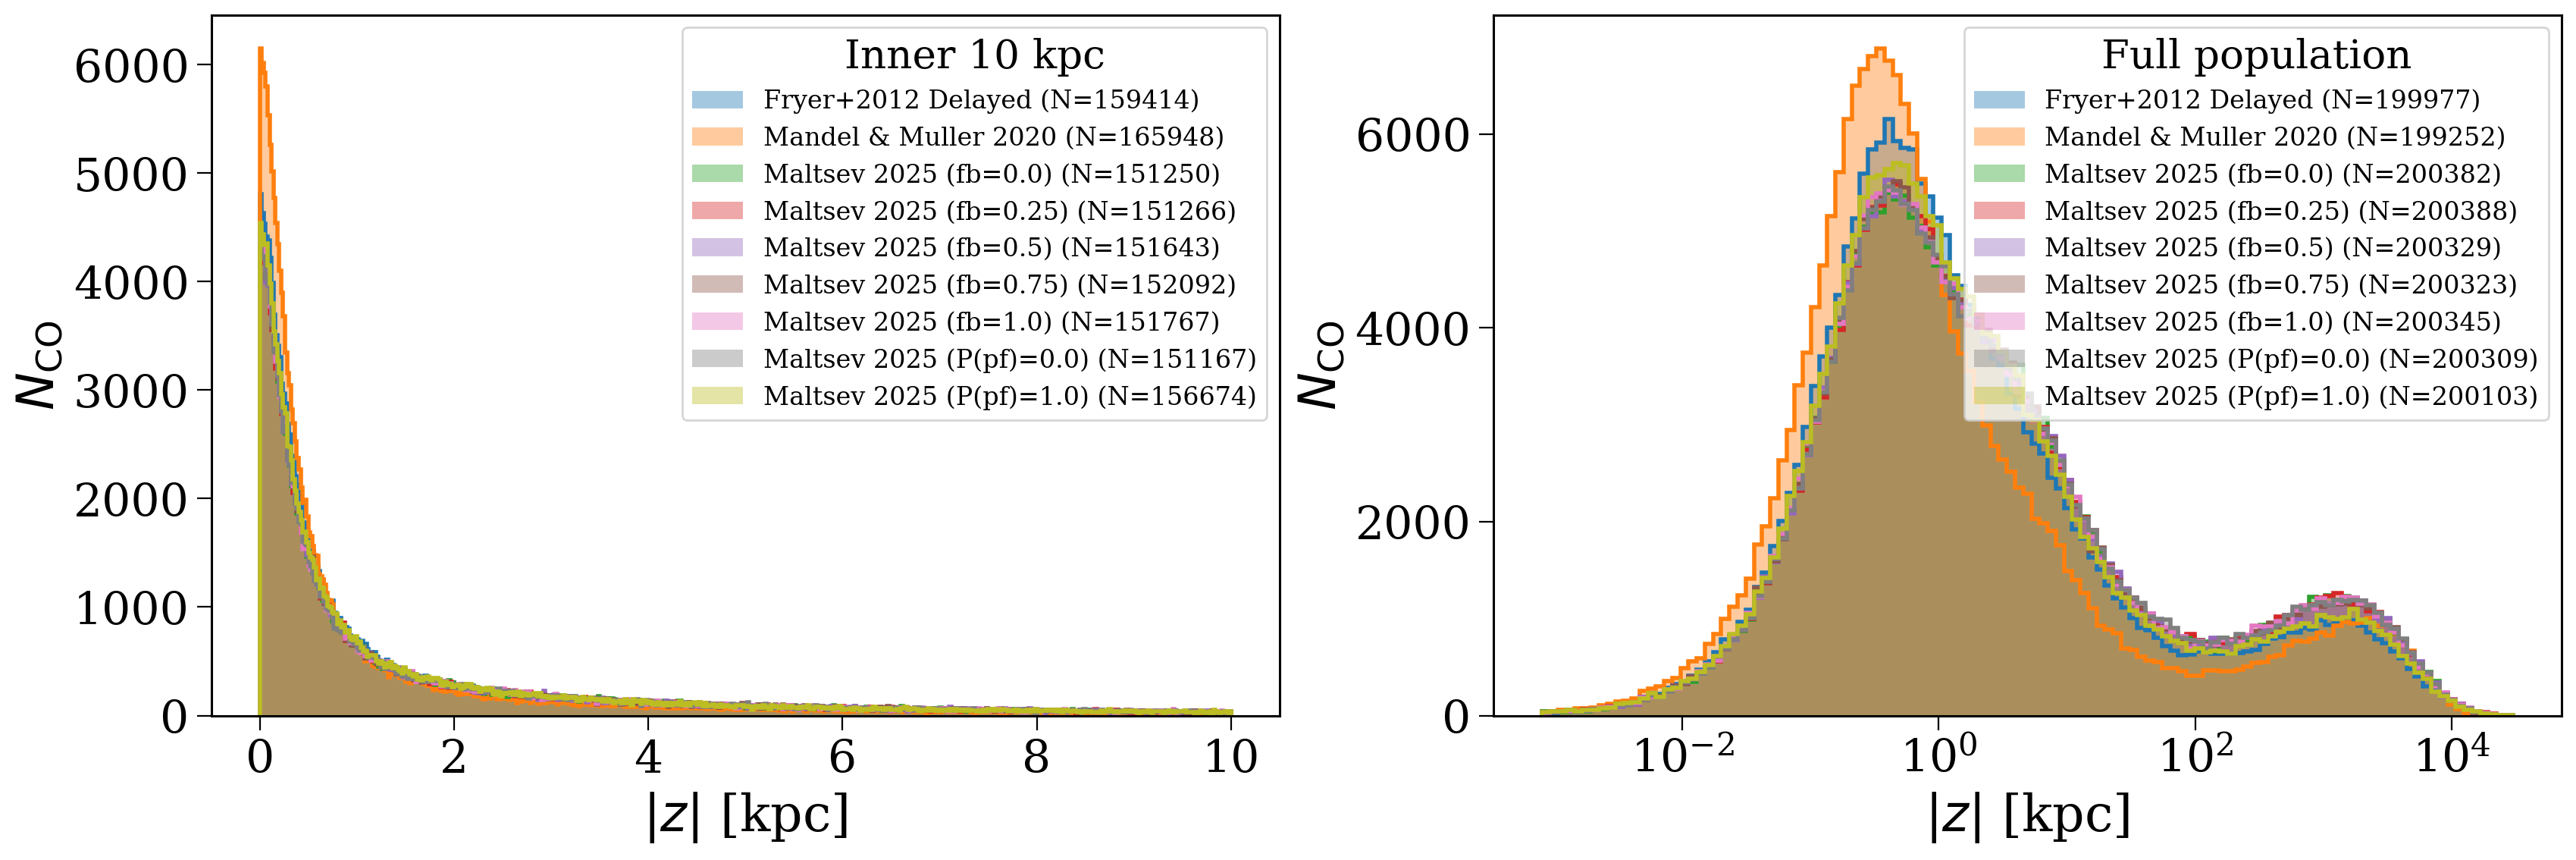

(<Figure size 2000x600 with 2 Axes>,
 array([<Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>,
        <Axes: xlabel='$|z|$ [kpc]', ylabel='$N_{\\rm CO}$'>], dtype=object))

In [98]:
plotting.absolute_galactocentric_height(pops, kinematics)

In [99]:
print("Escaped fractions:")
for pop in pops:
    escaped = kinematics[pop.label]["escaped"]["CO"]
    frac = escaped.sum() / len(escaped)
    print(f'  - {pop.label}:')
    print(f'      - CO = {kinematics[pop.label]["escaped"]["CO"].sum() / len(kinematics[pop.label]["escaped"]["CO"]):1.3f}')
    print(f'      - BH = {kinematics[pop.label]["escaped"]["BH"].sum() / len(kinematics[pop.label]["escaped"]["BH"]):1.3f}')
    print(f'      - NS = {kinematics[pop.label]["escaped"]["NS"].sum() / len(kinematics[pop.label]["escaped"]["NS"]):1.3f}')

Escaped fractions:
  - Fryer+2012 Delayed:
      - CO = 0.106
      - BH = 0.029
      - NS = 0.136
  - Mandel & Muller 2020:
      - CO = 0.104
      - BH = 0.000
      - NS = 0.160
  - Maltsev 2025 (fb=0.0):
      - CO = 0.133
      - BH = 0.000
      - NS = 0.142
  - Maltsev 2025 (fb=0.25):
      - CO = 0.132
      - BH = 0.009
      - NS = 0.141
  - Maltsev 2025 (fb=0.5):
      - CO = 0.131
      - BH = 0.005
      - NS = 0.142
  - Maltsev 2025 (fb=0.75):
      - CO = 0.129
      - BH = 0.000
      - NS = 0.140
  - Maltsev 2025 (fb=1.0):
      - CO = 0.131
      - BH = 0.000
      - NS = 0.142
  - Maltsev 2025 (P(pf)=0.0):
      - CO = 0.131
      - BH = 0.000
      - NS = 0.141
  - Maltsev 2025 (P(pf)=1.0):
      - CO = 0.114
      - BH = 0.019
      - NS = 0.138


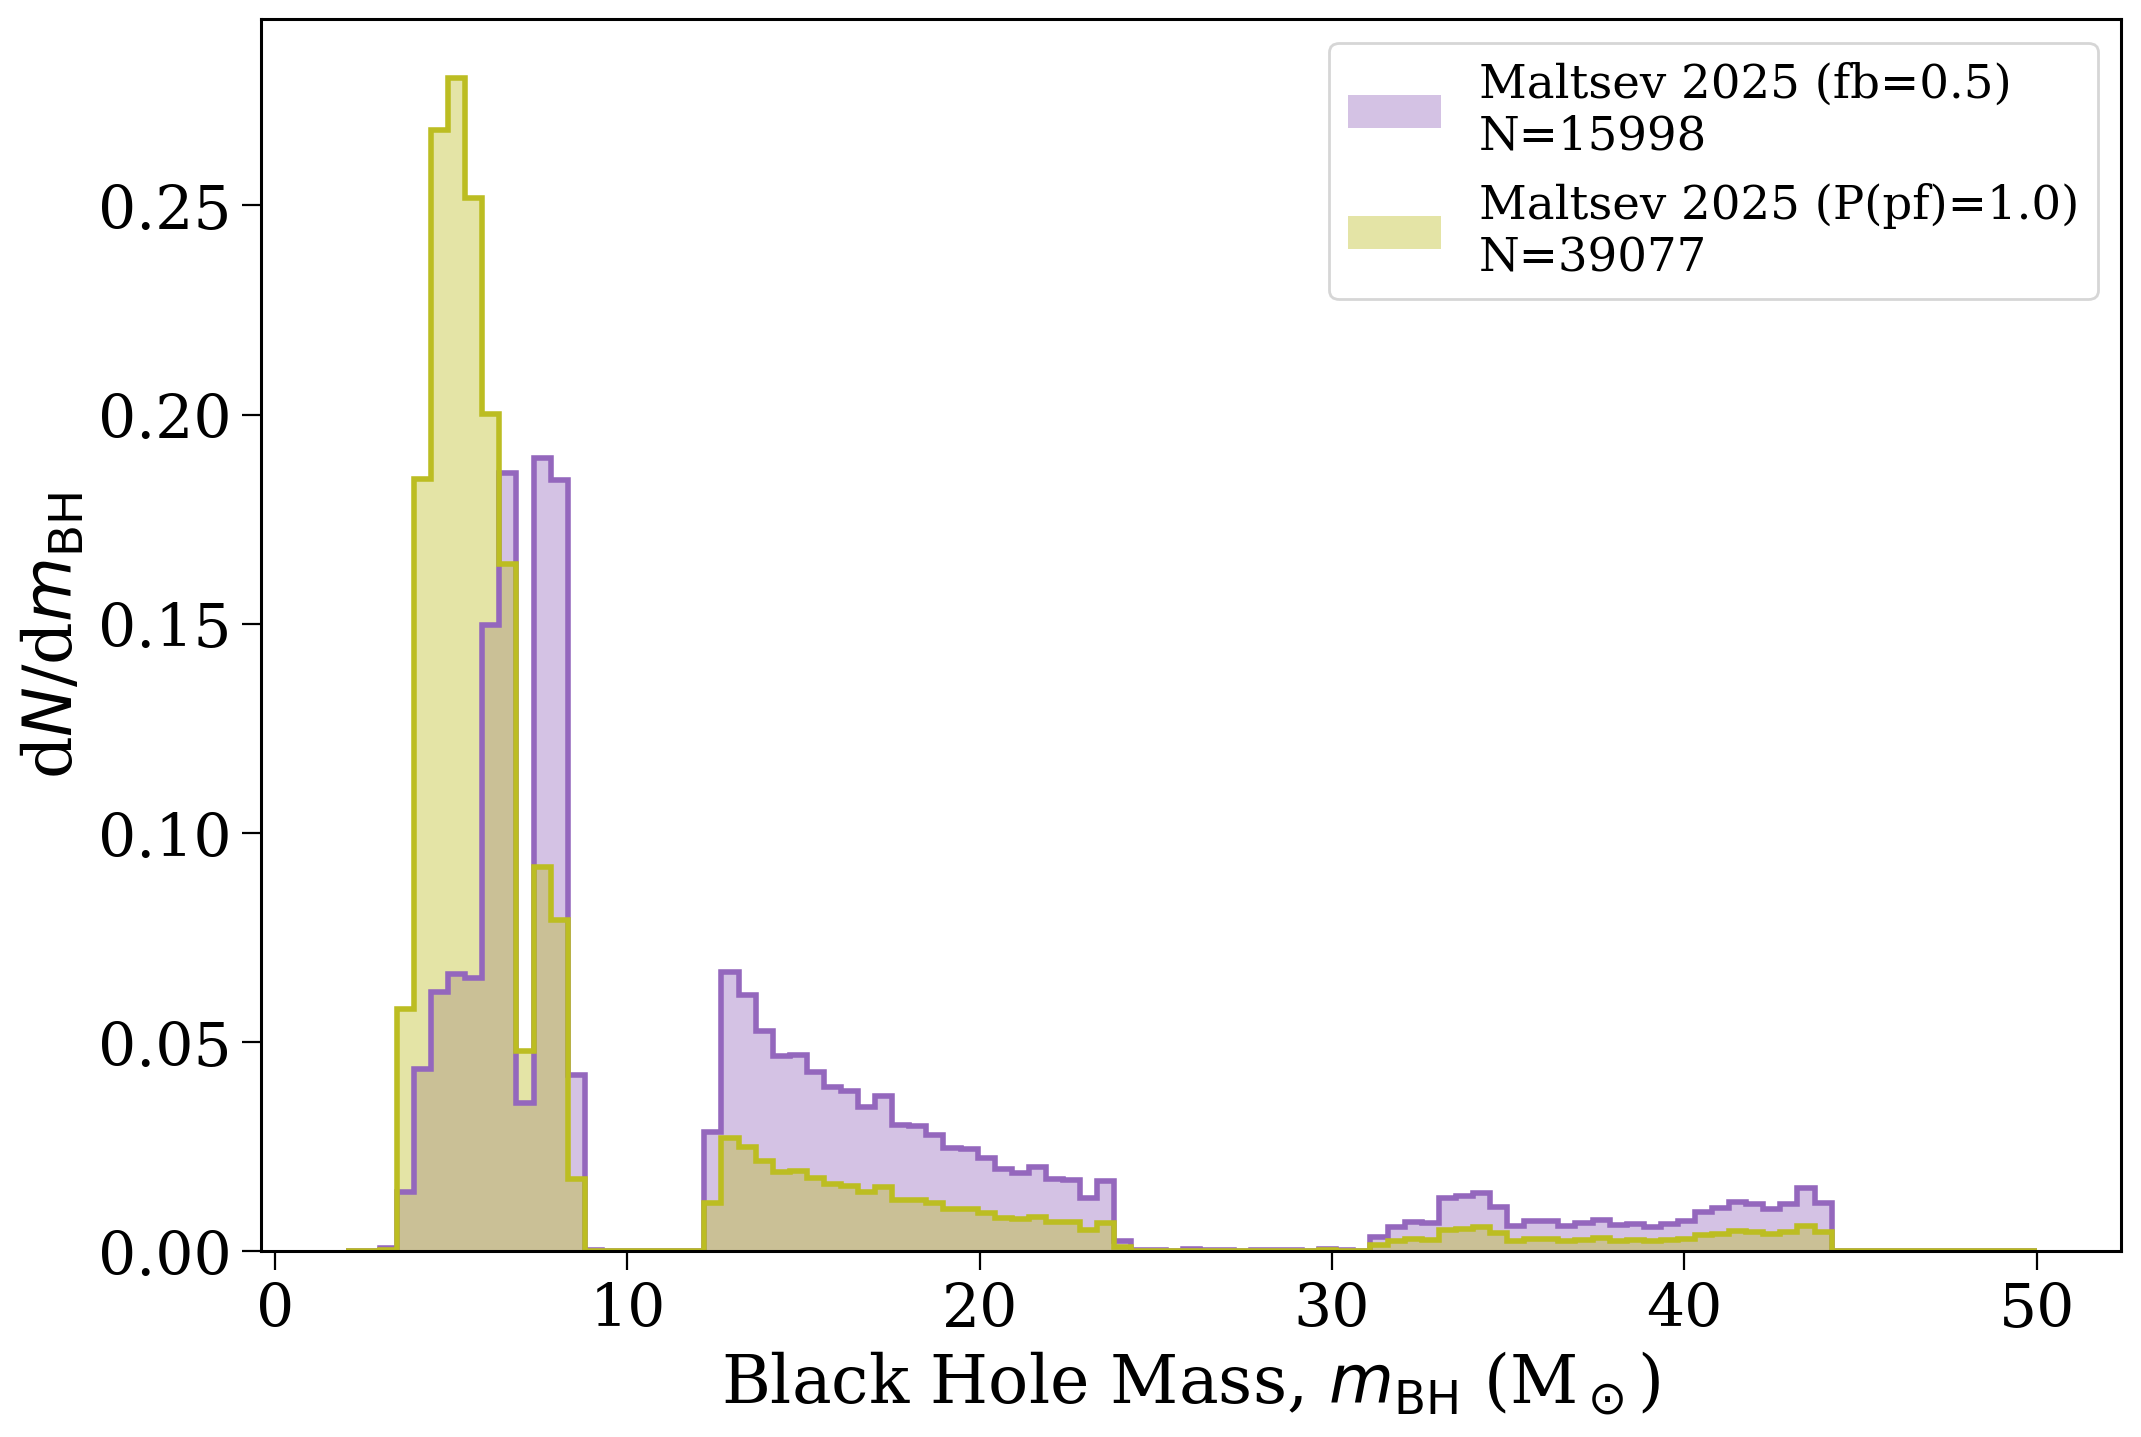

In [100]:
fig, ax = plotting.compare_table_quantity(
    pops=[pops[4], pops[-1]],
    quantity="mass",
    kstar=14,
    bins=np.linspace(2, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)

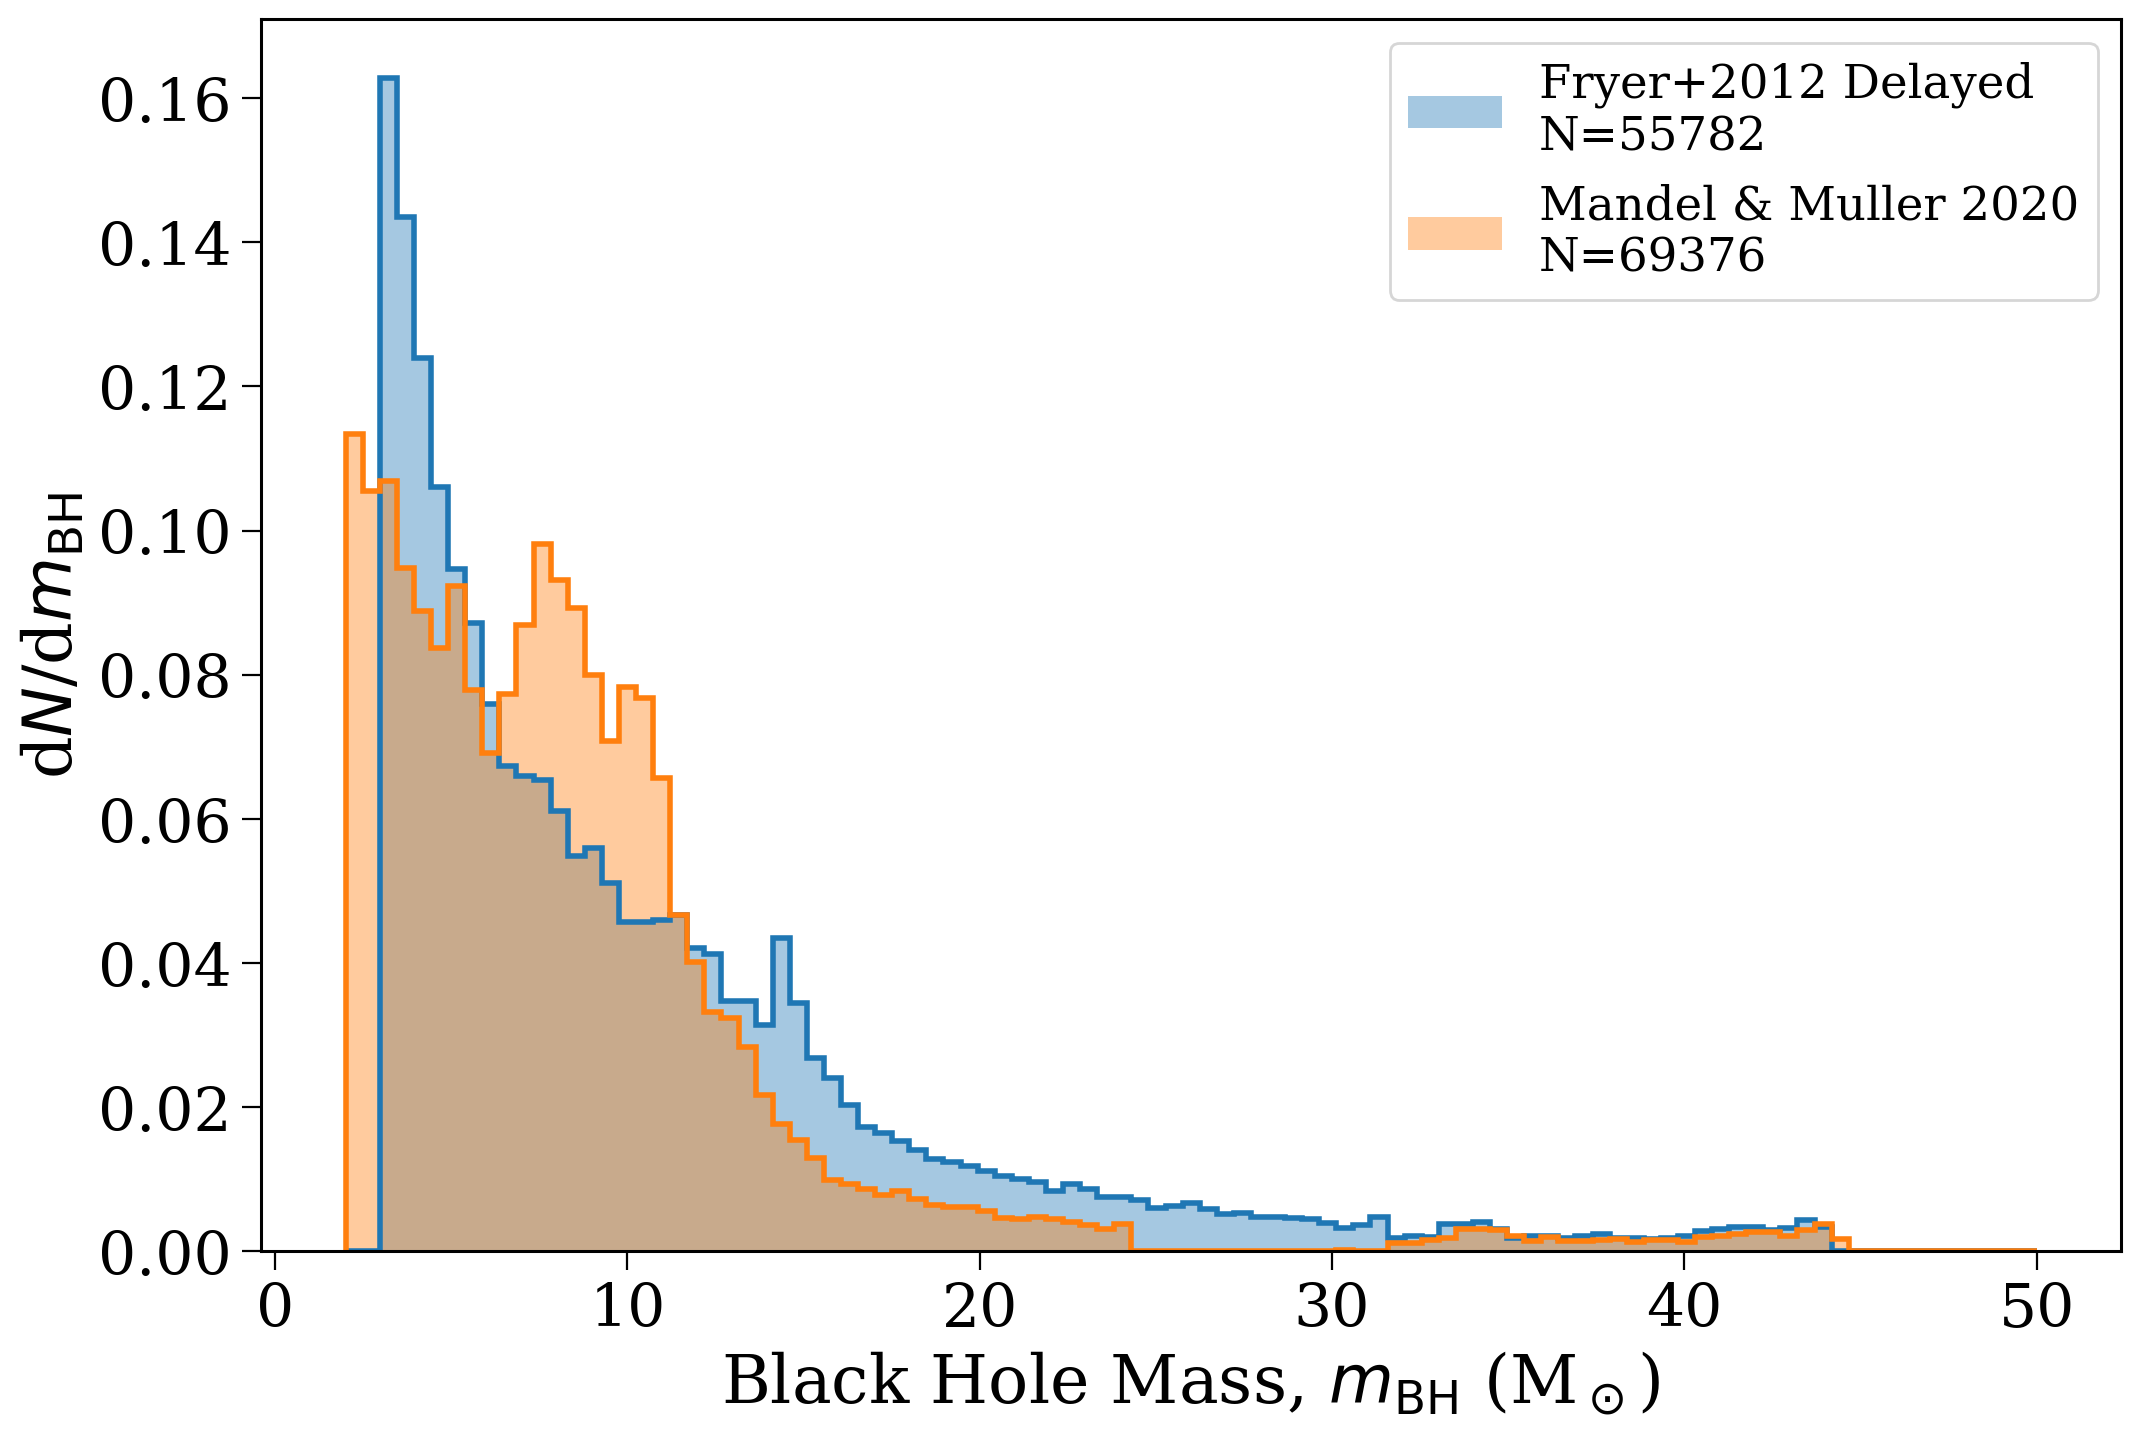

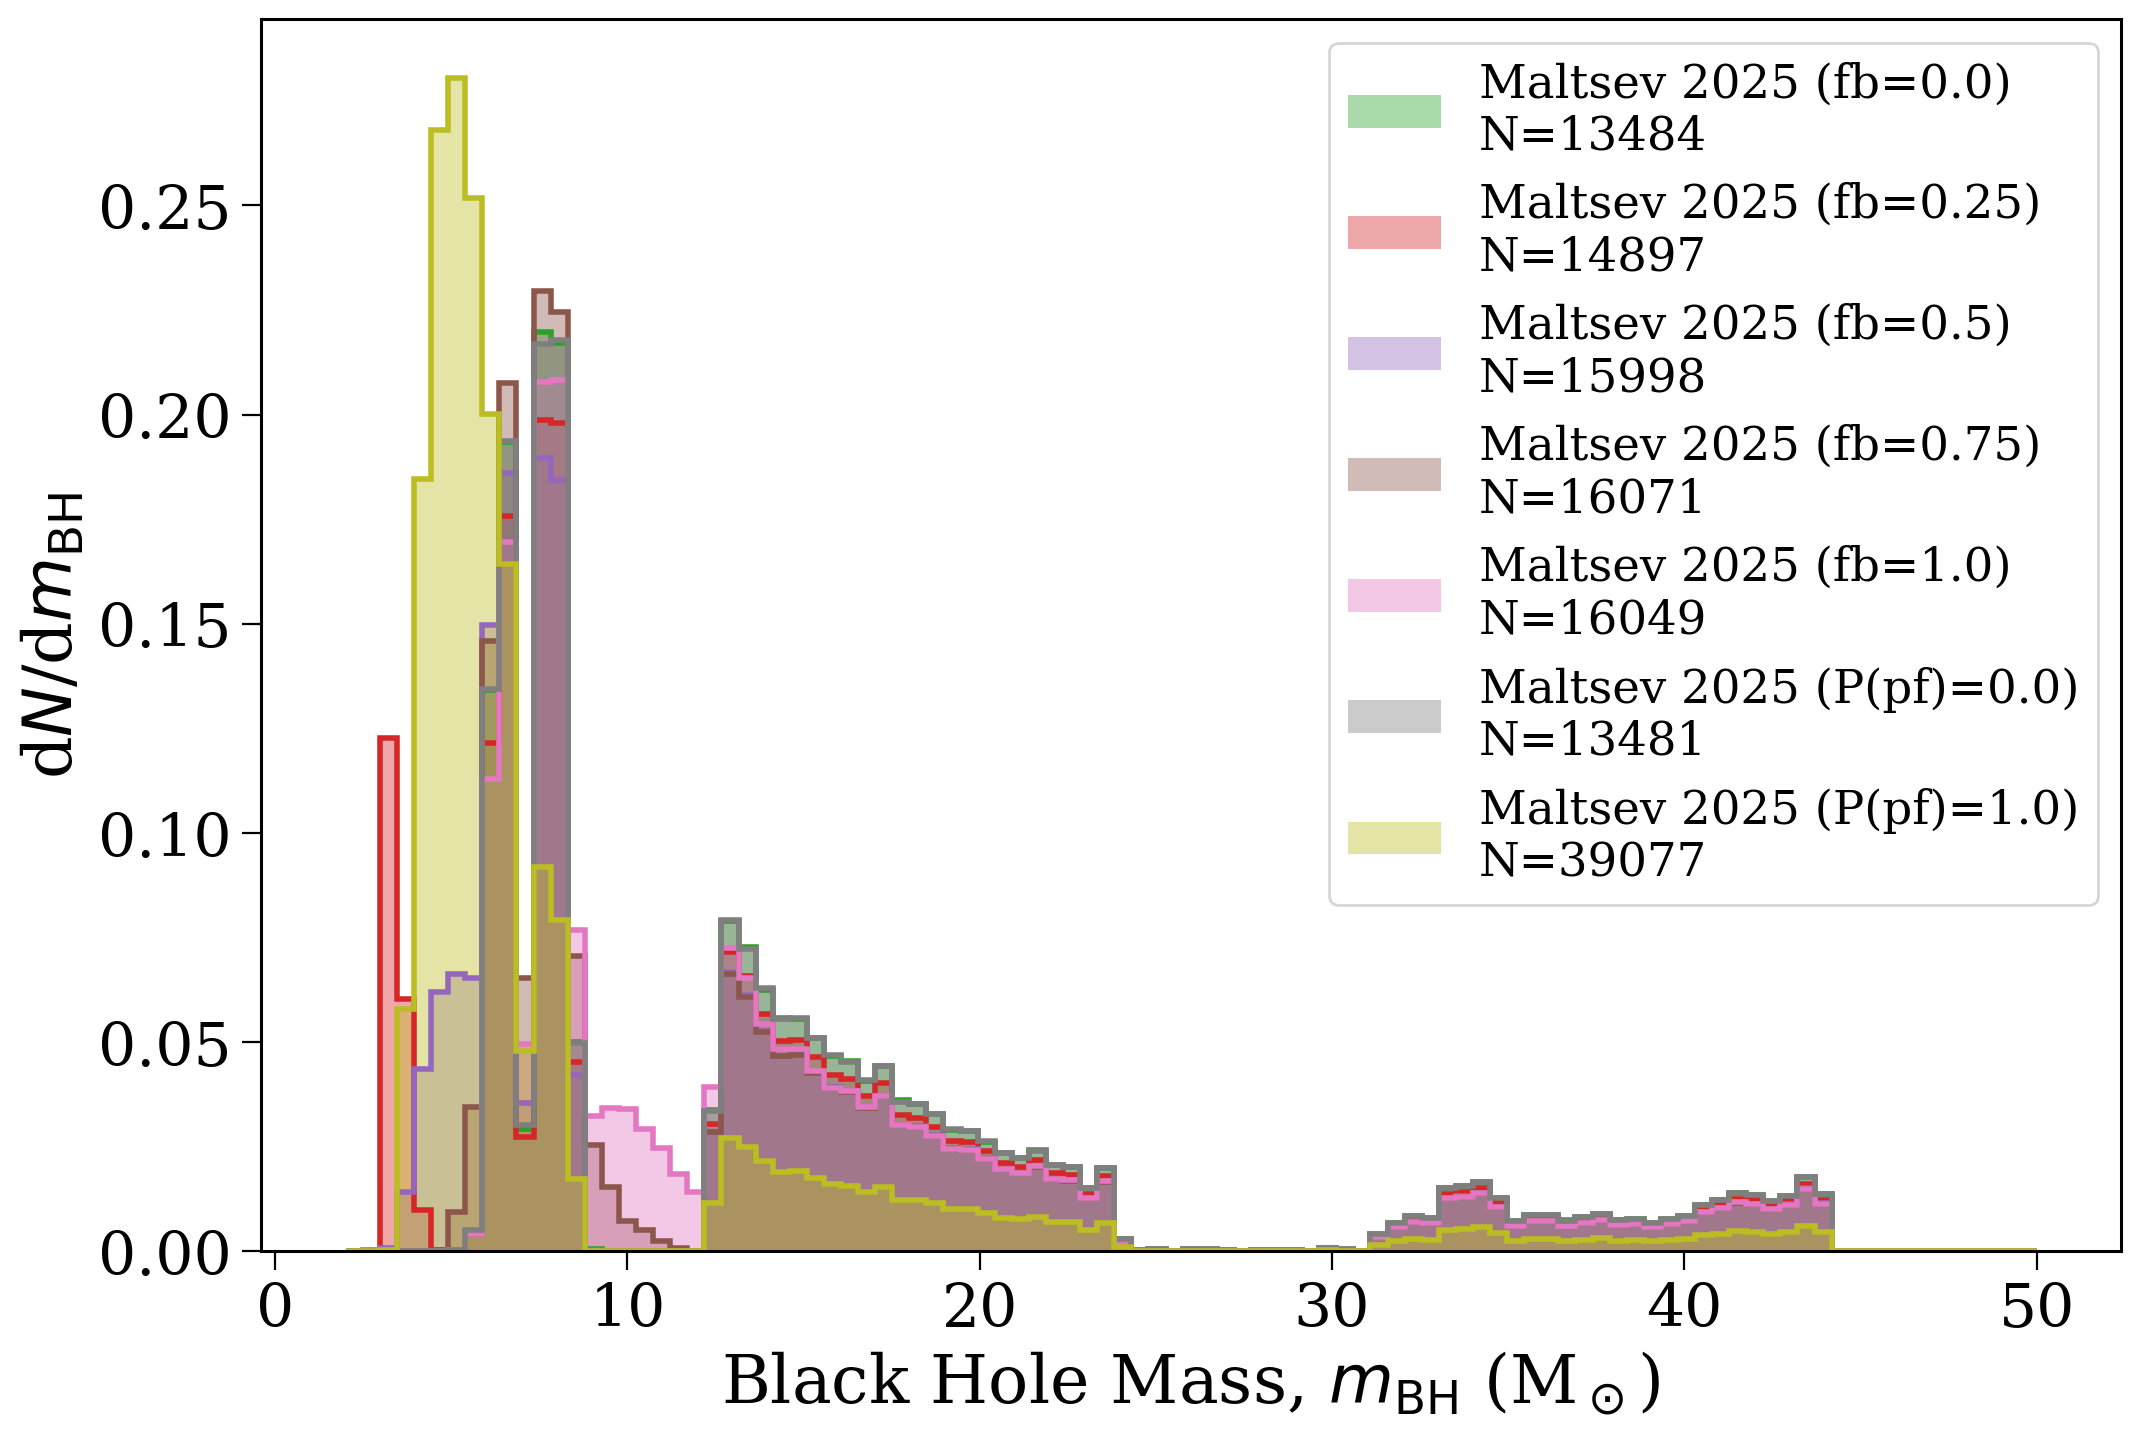

In [101]:
fig, ax = plotting.compare_table_quantity(
    pops=[p for p in pops if "Maltsev" not in p.label],
    quantity="mass",
    kstar=14,
    bins=np.linspace(2, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)

fig, ax = plotting.compare_table_quantity(
    pops=[p for p in pops if "Maltsev" in p.label],
    quantity="mass",
    kstar=14,
    bins=np.linspace(2, 50, 100),
    xlabel=r"Black Hole Mass, $m_{\rm BH}$ (M$_\odot$)",
    ylabel=r"d$N$/d$m_{\rm BH}$",
    show=False
)
plt.show()
# plotting.compare_table_quantity(
#     pops=pops,
#     quantity="mass",
#     kstar=13,
#     bins=np.linspace(1, 3, 101),
#     xlabel=r"Neutron star mass, $m_{\rm NS}$ (M$_\odot$)",
#     ylabel=r"d$N$/d$m_{\rm NS}$",
#     yscale='log'
# )

Fryer+2012 Delayed 11500 0.20822394032120806
Mandel & Muller 2020 21720 0.3216443549342495
Maltsev 2025 (fb=0.0) 13294 0.9990981512099805
Maltsev 2025 (fb=0.25) 13312 0.9048395867319196
Maltsev 2025 (fb=0.5) 13315 0.8429882874327319
Maltsev 2025 (fb=0.75) 13292 0.8390354753187729
Maltsev 2025 (fb=1.0) 15812 0.9989260218586139
Maltsev 2025 (P(pf)=0.0) 13290 0.9990227768172593
Maltsev 2025 (P(pf)=1.0) 13267 0.3433133216023186


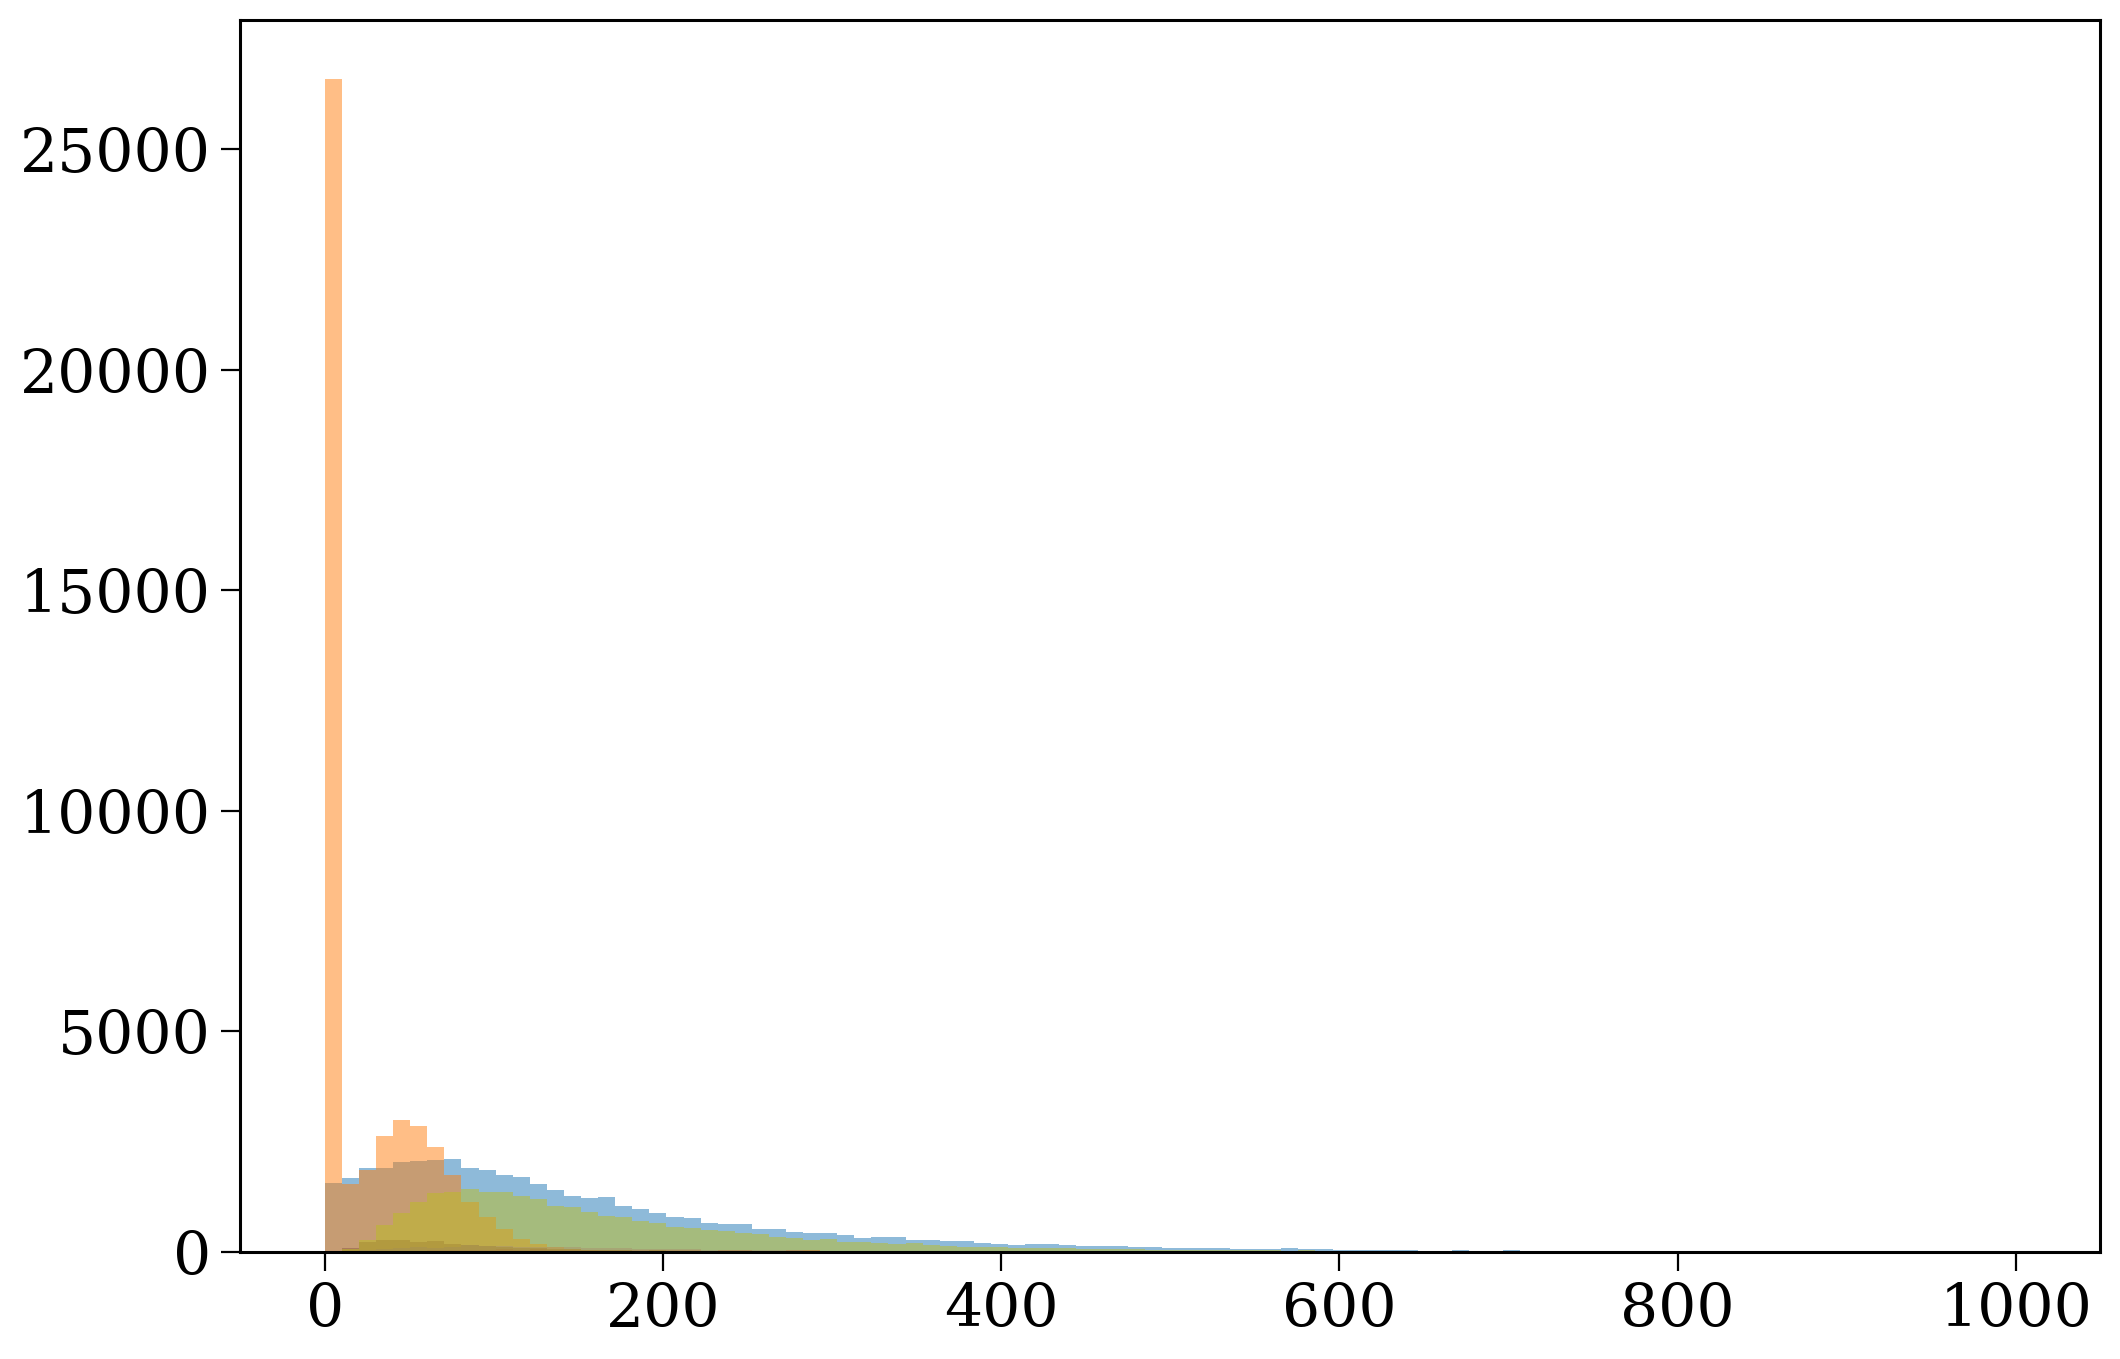

In [102]:
for pop in pops:

    kicks = []
    for ind in [1, 2]:
        kick_list = pop.kick_info.loc[pop.final_bpp["bin_num"][pop.final_bpp[f"kstar_{ind}"] == 14]]
        kicks = np.concatenate((kicks, kick_list[kick_list["star"] == ind]["natal_kick"].values))
        
    print(pop.label, (kicks == 0.0).sum(), (kicks == 0.0).sum() / len(kicks))
    kicks = kicks[kicks > 0.0]
    plt.hist(kicks, bins=np.linspace(0, 1000, 100), alpha=0.5, label=pop.label)

plt.show()

In [42]:
masses = {}

for pop in pops:
    mass = {
        "BH": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 14],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 14],
        )),
        "NS": np.concatenate((
            pop.final_bpp["mass_1"][pop.final_bpp["kstar_1"] == 13],
            pop.final_bpp["mass_2"][pop.final_bpp["kstar_2"] == 13],
        )),
    }
    mass["CO"] = np.concatenate((mass["NS"], mass["BH"]))
    masses[pop.label] = mass

In [55]:
z_range = np.geomspace(0.1, 10, 1000)

init_bh_z = np.concatenate((
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_1"] == 14],
    pops[0].initial_galaxy.z[pops[0].final_bpp["kstar_2"] == 14]
))
init_abs_z = np.abs(init_bh_z.to(u.kpc).value)

mean_masses = helpers.get_average_mass_at_z(
    abs_zs=[np.abs(kinematics[pop.label]["pos"]["BH"][:, 2].to(u.kpc).value)
            for pop in pops] + [init_abs_z],
    bh_masses=[masses[pop.label]["BH"] for pop in pops] + [masses[pops[0].label]["BH"]],
    z_range=z_range,
    window_width=0.1
)

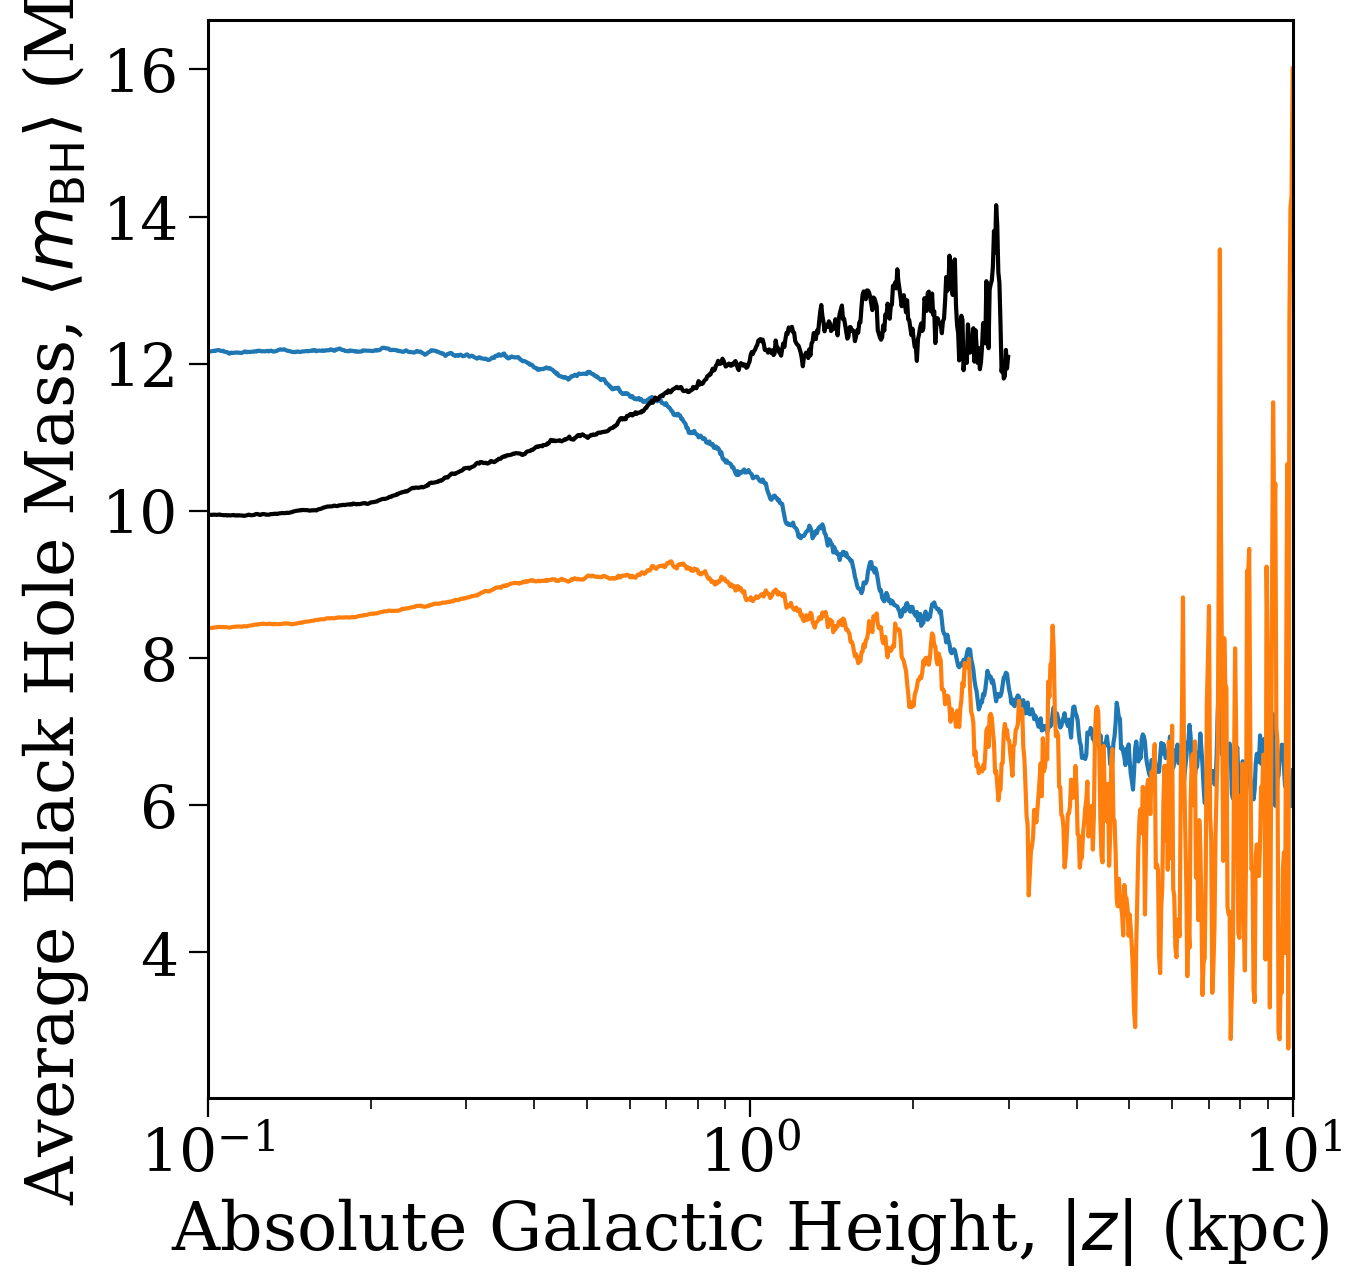

In [57]:
fig, ax = plt.subplots(figsize=(7, 7))

for i, pop in enumerate(pops):
    ax.plot(z_range, mean_masses[i], label=pop.label, color=pop.colour)
ax.plot(z_range[z_range < 3], mean_masses[-1][z_range < 3],
        label="Initial BHs", color="black")

ax.set(
    xscale='log',
    xlabel=r'Absolute Galactic Height, $|z|$ (kpc)',
    ylabel=r'Average Black Hole Mass, $\langle m_{\rm BH} \rangle$ (M$_\odot$)',
    xlim=(0.1, 10),
)

plt.show()

In [117]:
57 * scale_up

np.float64(188055.1105720529)

In [116]:
for pop in pops:

    bns_binary = (pop.bpp["kstar_1"] == 14) & (pop.bpp["kstar_2"] == 14) & (pop.bpp["sep"] > 0.0)
    bns_binary_nums = pop.bpp[bns_binary]["bin_num"].values

    merged_at_present_nums = pop.bin_nums[pop.final_bpp["sep"] == 0.0]

    bns_mergers = np.intersect1d(bns_binary_nums, merged_at_present_nums)
    print(f"{pop.label}: Number of BNS mergers at present: {len(bns_mergers)}")

Fryer+2012 Delayed: Number of BNS mergers at present: 57
Mandel & Muller 2020: Number of BNS mergers at present: 119
Maltsev 2025 (fb=0.0): Number of BNS mergers at present: 3
Maltsev 2025 (fb=0.25): Number of BNS mergers at present: 3
Maltsev 2025 (fb=0.5): Number of BNS mergers at present: 4
Maltsev 2025 (fb=0.75): Number of BNS mergers at present: 7
Maltsev 2025 (fb=1.0): Number of BNS mergers at present: 5
Maltsev 2025 (P(pf)=0.0): Number of BNS mergers at present: 3
Maltsev 2025 (P(pf)=1.0): Number of BNS mergers at present: 21


In [107]:
helpers.get_underworld_binaries(pops=pops)

{'Fryer+2012 Delayed': {'BH-BH':                tphys     mass_1     mass_2  kstar_1  kstar_2            sep  \
  153      4393.734686  15.116478  13.523117       14       14   19319.453976   
  200      9261.861150  14.615879  16.748364       14       14    3906.761984   
  999     10883.551678  21.490266  18.358395       14       14  233209.408980   
  1191     7766.690576  10.383292   5.896085       14       14     796.581284   
  1402    11587.180615  37.111384  34.729340       14       14  209365.181020   
  ...              ...        ...        ...      ...      ...            ...   
  317267  10826.521081  12.902836   4.712586       14       14      93.551114   
  317831   9369.260715  17.280291  16.558542       14       14   36538.929607   
  317929   6316.413001  13.914274  14.605669       14       14    6220.668613   
  318054    185.031095  18.003923  11.385168       14       14     137.625247   
  318237  11127.662535  26.182971  20.210736       14       14  100067.910340 